# 09 — Earnings-date effects

**Windows.** Pre = sessions −5…−1, event = 0, post = +1…+5, outside
otherwise. Distances use the exchange-session ordinal and the frozen LSEG
BMO/AMC/unknown/during-market mapping.

**Primary exploratory estimand.** Difference between each inside-window slope
and the outside-window slope for oriented `negative_share` on development
rows. One pooled regression, date-clustered errors, BH across three
interactions × h1. This is not a PEAD test.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import AGGREGATOR_NAMES, development_ic_table  # noqa: E402
from final_experiments.lib.earnings import (  # noqa: E402
    INTERACTION_FAMILY,
    WINDOW,
    attach_earnings_distance,
    earnings_interaction_table,
    map_earnings_sessions,
    read_quarterly_calendar,
)

OUTPUT = REPO_ROOT / "final_experiments" / "outputs" / "09_earnings"
OUTPUT.mkdir(parents=True, exist_ok=True)
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
TYPE_PATH = REPO_ROOT / "final_experiments" / "outputs" / "08_story_type" / "firm_day_story_types.parquet"
CALENDAR_PATH = REPO_ROOT / "final_experiments" / "data" / "earnings" / "fnspid_earnings_calendar_2011_2023_quarterly.csv"

print(f"windows: pre=-{WINDOW}..-1, event=0, post=1..{WINDOW}")
print("split: development through 2019-12-31")
print("cluster: session_date")
print("multiplicity:", INTERACTION_FAMILY)

windows: pre=-5..-1, event=0, post=1..5
split: development through 2019-12-31
cluster: session_date
multiplicity: pre/event/post interactions vs outside x h1; BH-FDR q=0.05


## Map calendar and attach nearest-event distance

In [2]:
agg = pd.read_parquet(AGG_PATH)
calendar = read_quarterly_calendar(CALENDAR_PATH)
mapped = map_earnings_sessions(calendar, agg["session_date"])
earnings = attach_earnings_distance(agg, mapped)
earnings.to_parquet(OUTPUT / "firm_day_earnings_windows.parquet", index=False)
window_mix = (
    earnings.groupby(["split", "earnings_window"], observed=True)
    .agg(firm_days=("symbol", "size"), symbols=("symbol", "nunique"), sessions=("session_date", "nunique"))
    .reset_index()
)
window_mix.to_csv(OUTPUT / "window_coverage.csv", index=False)
display(window_mix)

,split,earnings_window,firm_days,symbols,sessions
0,development,event,12779,468,1804
1,development,outside,420569,570,2264
2,development,post,44682,468,2217
3,development,pre,34123,468,2165
4,evaluation,event,4813,478,742
5,evaluation,outside,166098,570,998
6,evaluation,post,18012,482,978
7,evaluation,pre,14470,481,959


## Validate earnings-guidance clustering

This is a validation of the *machine taxonomy against the calendar*, not a
validation of the taxonomy against human labels.

In [3]:
types = pd.read_parquet(TYPE_PATH)
typed = earnings[["symbol", "session_date", "sessions_to_earnings"]].merge(
    types[["symbol", "session_date", "earnings_guidance_count", "typed_story_count"]],
    on=["symbol", "session_date"],
    how="inner",
)
guidance = typed.loc[typed["earnings_guidance_count"] > 0].copy()
validation = pd.DataFrame(
    [
        {
            "machine_earnings_guidance_firm_days": len(guidance),
            "within_event_session_share": float(guidance["sessions_to_earnings"].eq(0).mean()),
            "within_plus_minus_1_share": float(guidance["sessions_to_earnings"].abs().le(1).mean()),
            "within_plus_minus_5_share": float(guidance["sessions_to_earnings"].abs().le(5).mean()),
            "calendar_covered_share": float(guidance["sessions_to_earnings"].notna().mean()),
            "taxonomy_status": "PROVISIONAL_PENDING_HUMAN_AUDIT",
        }
    ]
)
validation.to_csv(OUTPUT / "earnings_guidance_calendar_validation.csv", index=False)
display(validation.T)

,0
machine_earnings_guidance_firm_days,176618
within_event_session_share,0.091327
within_plus_minus_1_share,0.239743
within_plus_minus_5_share,0.422709
calendar_covered_share,0.88602
taxonomy_status,PROVISIONAL_PENDING_HUMAN_AUDIT


## Pooled window interactions and timing sensitivity

,window,slope_delta_vs_outside,se,t,p,n_firm_days,n_dates,bh_reject_q05,multiplicity_family,cluster,sample
0,pre,0.000777,0.000554,1.403033,0.160607,34123,2165,False,pre/event/post interactions vs outside x h1; B...,session_date,all_frozen_timing_rules
1,event,0.000241,0.001401,0.172260,0.863233,12779,1804,False,pre/event/post interactions vs outside x h1; B...,session_date,all_frozen_timing_rules
2,post,-0.000772,0.000364,-2.121160,0.033908,44682,2217,False,pre/event/post interactions vs outside x h1; B...,session_date,all_frozen_timing_rules
3,pre,0.000840,0.000559,1.503279,0.132767,32823,2157,False,pre/event/post interactions vs outside x h1; B...,session_date,drop_inside_during_market_and_unknown
4,event,0.000383,0.001454,0.263527,0.792145,12252,1770,False,pre/event/post interactions vs outside x h1; B...,session_date,drop_inside_during_market_and_unknown
5,post,-0.000749,0.000373,-2.010422,0.044387,43161,2214,False,pre/event/post interactions vs outside x h1; B...,session_date,drop_inside_during_market_and_unknown


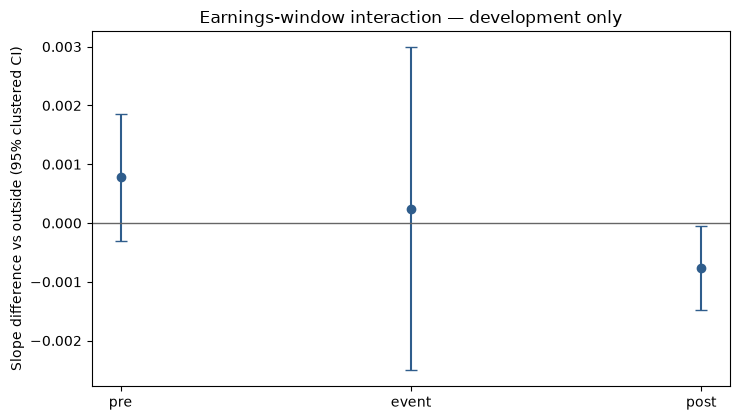

In [4]:
dev = earnings.loc[earnings["split"] == "development"].copy()
interactions = earnings_interaction_table(dev)
interactions["sample"] = "all_frozen_timing_rules"

# During-market rows can contaminate an open-to-open event-session outcome;
# unknown-time rows use the conservative next-session convention. Remove both
# only when the nearest event is inside the declared window.
uncertain_inside = dev["inside_earnings_window"] & dev["nearest_earnings_timing"].isin(["during_market", "unknown"])
sensitivity = earnings_interaction_table(dev.loc[~uncertain_inside])
sensitivity["sample"] = "drop_inside_during_market_and_unknown"
interaction_all = pd.concat([interactions, sensitivity], ignore_index=True)
interaction_all.to_csv(OUTPUT / "development_earnings_interactions.csv", index=False)
display(interaction_all.round(6))

plot = interactions.set_index("window").loc[["pre", "event", "post"]]
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.errorbar(
    plot.index,
    plot["slope_delta_vs_outside"],
    yerr=1.96 * plot["se"],
    fmt="o",
    color="#2f5d8c",
    capsize=4,
)
ax.axhline(0, color="#666", lw=1)
ax.set_ylabel("Slope difference vs outside (95% clustered CI)")
ax.set_title("Earnings-window interaction — development only")
fig.tight_layout()
fig.savefig(OUTPUT / "development_earnings_interactions.png", dpi=150)
plt.show()

## Exclusion robustness for the complete W3 family

Re-run the nine-rule development family after dropping every ±5-session
earnings-window firm-day. BH is recomputed within the same nine-rule family.

In [5]:
outside = earnings.loc[~earnings["inside_earnings_window"]].copy()
outside_ic = development_ic_table(outside, aggregators=AGGREGATOR_NAMES, by_n_bin=False)
outside_ic.to_csv(OUTPUT / "development_ic_excluding_earnings_windows.csv", index=False)
display(outside_ic.sort_values("p").round(6))

manifest = {
    "estimand": "inside-window slope differences vs outside for oriented negative_share",
    "split": "development <= 2019-12-31",
    "windows": {"pre": [-5, -1], "event": [0, 0], "post": [1, 5]},
    "cluster": "session_date",
    "multiplicity_family": INTERACTION_FAMILY,
    "calendar_rows": len(calendar),
    "mapped_calendar_rows": len(mapped),
    "bh_surviving_interactions": int(interactions["bh_reject_q05"].sum()),
    "exclusion_family": "nine aggregators x h1; BH-FDR q=0.05",
    "pead_boundary": "No post-earnings drift claim: outcome is next-session h1 and windows are conditioning variables.",
    "limitations": [
        "earnings-guidance taxonomy remains provisional pending human audit",
        "recoverable calendar mapping and issuer-title coverage holes remain documented",
        "during-market event-session returns can include pre-announcement trading",
    ],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

,stratum,aggregator,outcome,n,n_clusters,n_dates_total,min_names,hac_lags,inference,ic,se,t,p,bh_reject_q05,bh_family
4,all,negative_share,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,-0.005508,0.001899,-2.900816,0.003722,True,nine aggregators × primary horizon h1; n-bin s...
8,all,decayed_state,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.004997,0.001981,2.522626,0.011648,False,nine aggregators × primary horizon h1; n-bin s...
2,all,median_continuous,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.003490,0.001877,1.859126,0.063009,False,nine aggregators × primary horizon h1; n-bin s...
6,all,strongest_event,ar_open_h1,420561,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.003565,0.001918,1.858249,0.063134,False,nine aggregators × primary horizon h1; n-bin s...
7,all,attention_log_n,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.003590,0.001964,1.827953,0.067557,False,nine aggregators × primary horizon h1; n-bin s...
0,all,mean_hard_label,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.003246,0.001898,1.709733,0.087315,False,nine aggregators × primary horizon h1; n-bin s...
1,all,mean_continuous,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.003246,0.001930,1.682279,0.092515,False,nine aggregators × primary horizon h1; n-bin s...
3,all,trimmed_mean,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.003241,0.001930,1.679503,0.093054,False,nine aggregators × primary horizon h1; n-bin s...
5,all,dispersion,ar_open_h1,420565,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,-0.001166,0.001710,-0.681862,0.495326,False,nine aggregators × primary horizon h1; n-bin s...


{
  "estimand": "inside-window slope differences vs outside for oriented negative_share",
  "split": "development <= 2019-12-31",
  "windows": {
    "pre": [
      -5,
      -1
    ],
    "event": [
      0,
      0
    ],
    "post": [
      1,
      5
    ]
  },
  "cluster": "session_date",
  "multiplicity_family": "pre/event/post interactions vs outside x h1; BH-FDR q=0.05",
  "calendar_rows": 22883,
  "mapped_calendar_rows": 22856,
  "bh_surviving_interactions": 0,
  "exclusion_family": "nine aggregators x h1; BH-FDR q=0.05",
  "pead_boundary": "No post-earnings drift claim: outcome is next-session h1 and windows are conditioning variables.",
  "limitations": [
    "earnings-guidance taxonomy remains provisional pending human audit",
    "recoverable calendar mapping and issuer-title coverage holes remain documented",
    "during-market event-session returns can include pre-announcement trading"
  ]
}
